# Semana 1 — Baseline com Dados Tabulares
**Dataset:** Breast Cancer Wisconsin (scikit-learn)  

## 1. Importações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Avaliação
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)

RANDOM_STATE = 42
print("Importações concluídas.")

Importações concluídas.


## 2. Carregar e explorar o dataset

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df['diagnosis'] = df['target'].map({0: 'Maligno', 1: 'Benigno'})

print(f"Shape: {X.shape}")
print(f"Classes: {data.target_names}")
print(f"\nDistribuição de classes:")
print(df['diagnosis'].value_counts())
print(f"\nPercentagem:")
print(df['diagnosis'].value_counts(normalize=True).mul(100).round(1))

Shape: (569, 30)
Classes: ['malignant' 'benign']

Distribuição de classes:
diagnosis
Benigno    357
Maligno    212
Name: count, dtype: int64

Percentagem:
diagnosis
Benigno    62.7
Maligno    37.3
Name: proportion, dtype: float64


In [3]:
# Estatísticas descritivas
df.drop(columns=['target', 'diagnosis']).describe().round(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


### 2.1 Distribuição de classes

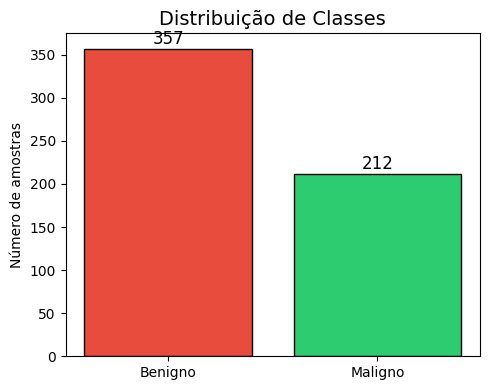

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['diagnosis'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax.set_title('Distribuição de Classes', fontsize=14)
ax.set_ylabel('Número de amostras')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('distribuicao_classes.png', dpi=150)
plt.show()

### 2.2 Escalas das variáveis — boxplots por classe

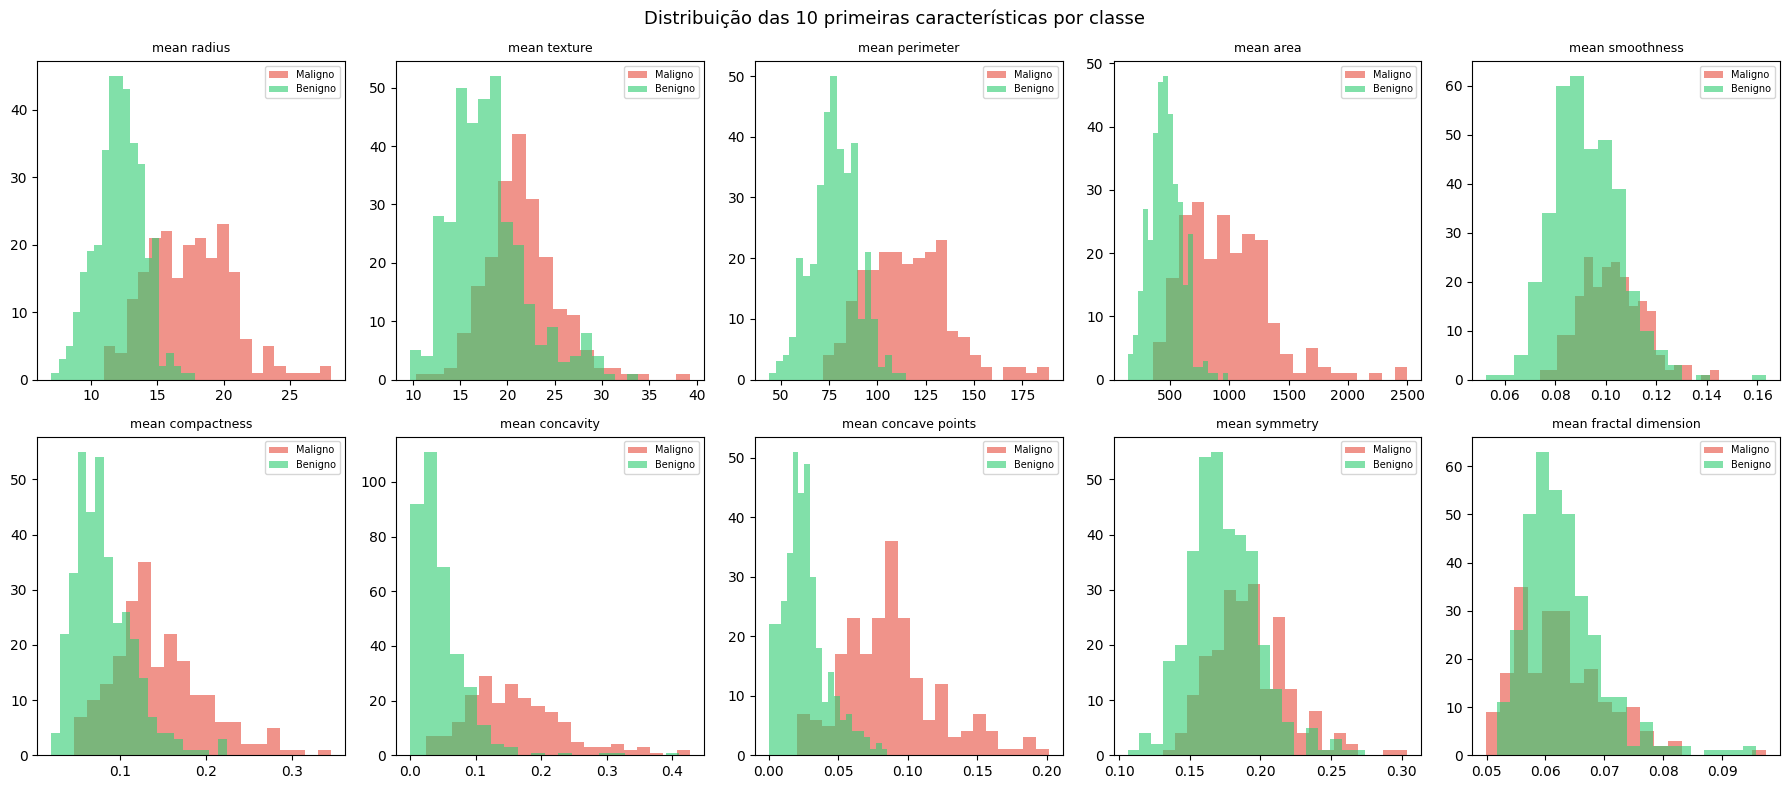

In [5]:
# As primeiras 10 features (mean values) são as mais interpretáveis
mean_features = data.feature_names[:10]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(mean_features):
    for label, color in zip(['Maligno', 'Benigno'], ['#e74c3c', '#2ecc71']):
        subset = df[df['diagnosis'] == label][feat]
        axes[i].hist(subset, bins=20, alpha=0.6, label=label, color=color)
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle('Distribuição das 10 primeiras características por classe', fontsize=13)
plt.tight_layout()
plt.savefig('distribuicao_features.png', dpi=150)
plt.show()

### 2.3 Correlação entre features

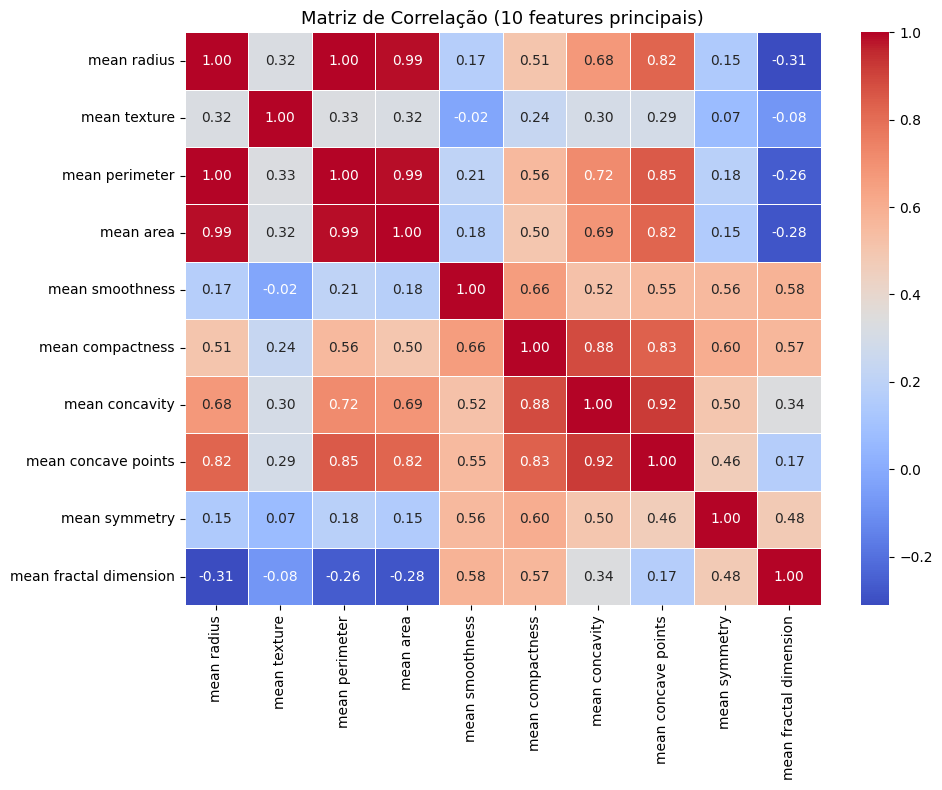

In [6]:
corr = df[data.feature_names[:10]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlação (10 features principais)', fontsize=13)
plt.tight_layout()
plt.savefig('correlacao.png', dpi=150)
plt.show()

## 3. Preparar os dados

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"\nDistribuição no treino: {np.bincount(y_train)}")
print(f"Distribuição no teste:  {np.bincount(y_test)}")

Treino: 455 amostras
Teste:  114 amostras

Distribuição no treino: [170 285]
Distribuição no teste:  [42 72]


## 4. Treinar e avaliar os modelos

In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=10000, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'SVM (RBF)':           SVC(probability=True, random_state=RANDOM_STATE),
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', model),
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'pipeline': pipe, 'y_pred': y_pred, 'y_prob': y_prob, 'auc': auc}
    print(f"\n{'='*50}")
    print(f"  {name}  |  AUC-ROC: {auc:.4f}")
    print('='*50)
    print(classification_report(y_test, y_pred, target_names=data.target_names))


  Logistic Regression  |  AUC-ROC: 0.9954
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


  Random Forest  |  AUC-ROC: 0.9939
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


  SVM (RBF)  |  AUC-ROC: 0.9950
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg   

## 5. Confusion Matrix

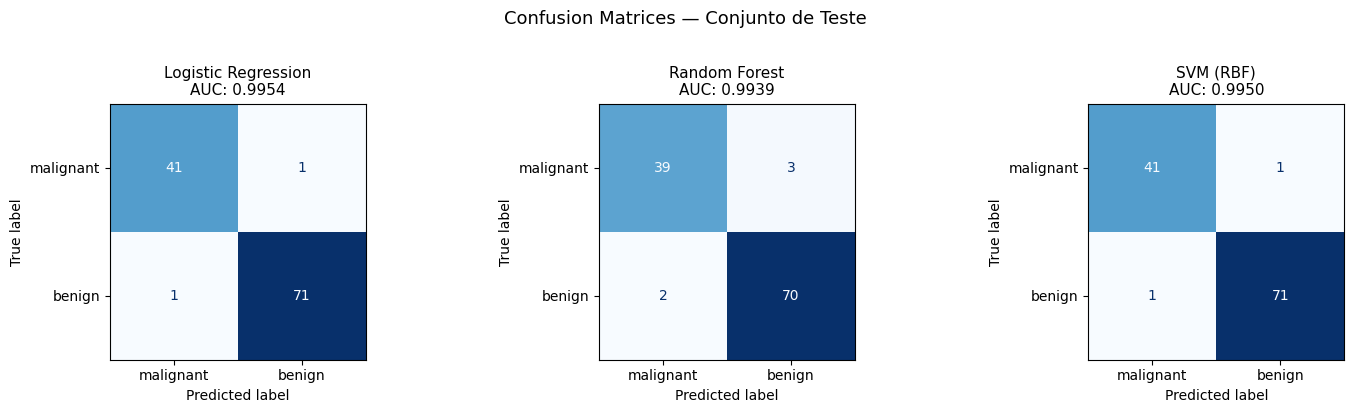

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=data.target_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAUC: {res["auc"]:.4f}', fontsize=11)

plt.suptitle('Confusion Matrices — Conjunto de Teste', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

## 6. Curva ROC

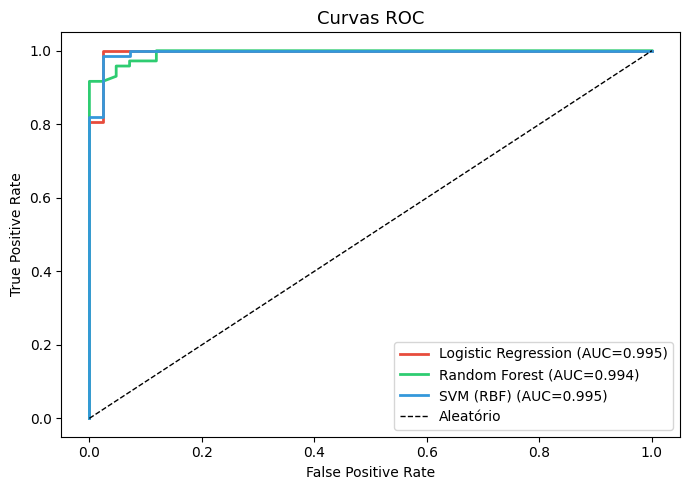

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = ['#e74c3c', '#2ecc71', '#3498db']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatório')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('curva_roc.png', dpi=150)
plt.show()

## 7. Importância das features (Random Forest)

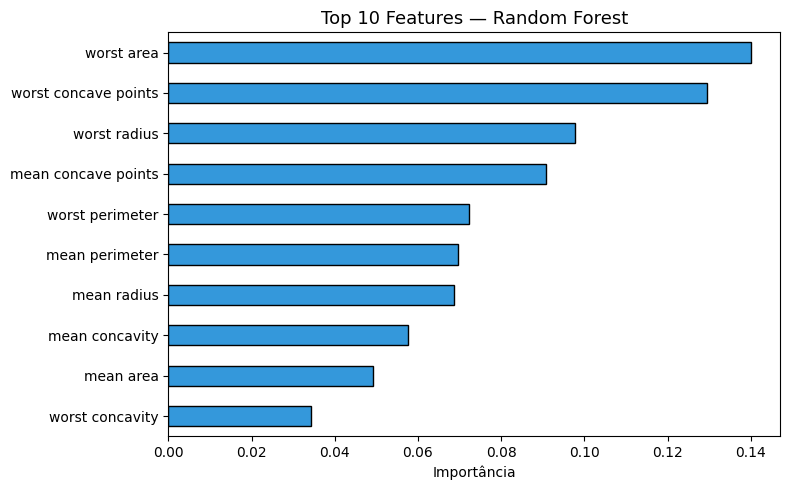

worst area              0.1400
worst concave points    0.1295
worst radius            0.0977
mean concave points     0.0909
worst perimeter         0.0722
mean perimeter          0.0696
mean radius             0.0687
mean concavity          0.0576
mean area               0.0492
worst concavity         0.0343
dtype: float64


In [11]:
rf_model = results['Random Forest']['pipeline'].named_steps['clf']
importances = pd.Series(rf_model.feature_importances_, index=data.feature_names)
top10 = importances.nlargest(10)

fig, ax = plt.subplots(figsize=(8, 5))
top10.sort_values().plot(kind='barh', ax=ax, color='#3498db', edgecolor='black')
ax.set_title('Top 10 Features — Random Forest', fontsize=13)
ax.set_xlabel('Importância')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print(top10.round(4))

## 8. Resumo dos resultados

In [12]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

summary = []
for name, res in results.items():
    yp = res['y_pred']
    summary.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp),
        'Recall': recall_score(y_test, yp),
        'F1': f1_score(y_test, yp),
        'AUC-ROC': res['auc'],
    })

pd.DataFrame(summary).set_index('Modelo').round(4)

,Accuracy,Precision,Recall,F1,AUC-ROC
Modelo,,,,,
Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954
Random Forest,0.9561,0.9589,0.9722,0.9655,0.9939
SVM (RBF),0.9825,0.9861,0.9861,0.9861,0.9950
